<a href="https://colab.research.google.com/github/grjadhav409/Prediction-of-active-molecules-against-breast-cancer-cells/blob/main/1_descriptor_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
# ! pip install padelpy
# from padelpy import from_smiles

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/grjadhav409/grjadhav409-prediction-of-active-molecules-against-breast-cancer-cells/main/data/MCF-7.csv")
df

,Smiles,Label
0,O(CCCCCCCCCC)c1cc2n(c3c(c2cc1)ccnc3C)CCCC,0
1,O(CCCCCCCC)c1cc2n(c3c(c2cc1)ccnc3C)CCCc1ccccc1,0
2,O(CCCC)c1cc2n(c3c(c2cc1)ccnc3C)CC(C)C,1
3,O(CCCC)c1cc2n(c3c(c2cc1)ccnc3C)CCCC,0
4,Oc1cc2n(c3c(c2cc1)ccnc3C)CCCC,0
...,...,...
29373,n12N=C(N=Nc1nnc2)N1CCCC1,1
29374,n12N=C(N=Nc1nnc2)N1CCCCC1,0
29375,O1CCN(CC1)C=1N=Nc2n(N=1)cnn2,1
29376,[NH+]=1n2c(nnc2)N=NC=1NC1CCCC1,0


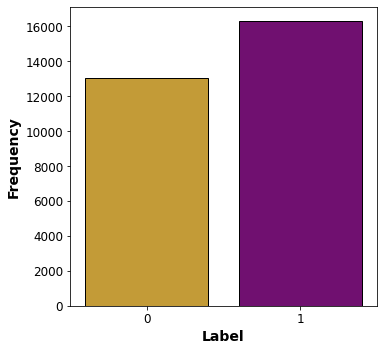

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='Label', data=df, palette = ["goldenrod", "purple"], edgecolor='black')

plt.xlabel('Label', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('figures/plot_bioactivity_class.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
smiles = df['Smiles'].tolist()

#padel

In [ ]:
"""
A= []
for i in smiles:
  c =from_smiles(i, fingerprints=True, descriptors=True)
  A.append(c)
discriptors = pd.DataFrame(data = A)
"""

'\nA= []\nfor i in smiles:\n  c =from_smiles(i, fingerprints=True, descriptors=True)\n  A.append(c)\ndiscriptors = pd.DataFrame(data = A)\n'

In [ ]:
"""
X_padel = discriptors
X_padel
"""

'\nX_padel = discriptors\nX_padel\n'

In [ ]:
"""
X_padel.to_csv('X_padel.csv')
!cp X_padel.csv "/content/drive/MyDrive/Colab Notebooks/NCL"
"""

'\nX_padel.to_csv(\'X_padel.csv\')\n!cp X_padel.csv "/content/drive/MyDrive/Colab Notebooks/NCL"\n'

# deepchem

In [ ]:
!pip install deepchem
!pip install git+https://github.com/mordred-descriptor/mordred
!pip install rdkit-pypi
!pip install pubchempy


import deepchem as dc
import numpy as np
import pandas as pd

In [ ]:
#featurizer = dc.feat.CircularFingerprint(size=1024)
#featurizer = dc.feat.MACCSKeysFingerprint()
#featurizer=dc.feat.ConvMolFeaturizer(per_atom_fragmentation=True)
#featurizer = dc.feat.PubChemFingerprint() #required rdkit and pubchempy installed
featurizer = dc.feat.RDKitDescriptors(use_fragment=True, ipc_avg=True)
#featurizer = dc.feat.MordredDescriptors(ignore_3D = False)
#featurizer = dc.feat.WeaveFeaturizer()
#featurizer = dc.feat.MATFeaturizer()
#featurizer = dc.feat.Mol2VecFingerprint()
#featurizers = dc.feat.CoulombMatrix(max_atoms=23)
#featurizers = dc.feat.CoulombMatrixEig(max_atoms=23)
#featurizer = dc.feat.AtomicCoordinates(use_bohr=False)
#featurizer = dc.feat.BPSymmetryFunctionInput(max_atoms=10)
#featurizer = dc.feat.ElementPropertyFingerprint()



discriptors = featurizer.featurize(smiles)


X_rdkit = pd.DataFrame(data=discriptors)
X_rdkit

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,6.115972,0.815713,6.115972,0.815713,0.276277,394.603,356.299,394.298414,158.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0
1,6.146728,0.798066,6.146728,0.798066,0.214643,428.620,392.332,428.282764,168.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
2,5.911770,0.581548,5.911770,0.581548,0.575113,310.441,284.233,310.204513,122.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5.911263,0.789463,5.911263,0.789463,0.540468,310.441,284.233,310.204513,122.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9.745605,0.318210,9.745605,0.318210,0.766685,254.333,236.189,254.141913,98.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29373,4.261204,0.437914,4.261204,0.437914,0.605558,191.198,182.126,191.091943,72.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29374,4.302870,0.440518,4.302870,0.440518,0.647242,205.225,194.137,205.107593,78.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29375,5.244551,0.409268,5.244551,0.409268,0.577511,207.197,198.125,207.086858,78.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29376,4.002593,0.478678,4.002593,0.478678,0.728297,206.233,194.137,206.114870,78.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
Y= df['Label']
Y

0        0
1        0
2        1
3        0
4        0
        ..
29373    1
29374    0
29375    1
29376    0
29377    1
Name: Label, Length: 29378, dtype: int64

In [ ]:
X_rdkit.to_csv('X_rdkit.csv')
!cp X_rdkit.csv "/content/drive/MyDrive/Colab Notebooks/NCL"

In [ ]:
Y.to_csv('Y.csv')
!cp Y.csv "/content/drive/MyDrive/Colab Notebooks/NCL"